In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_lyapunov
from mpmath import quad, invertlaplace
import mpmath as mp
import math
from tqdm import tqdm
from scipy.linalg import matmul_toeplitz
from scipy.signal import fftconvolve
from scipy.integrate import odeint, solve_ivp
from scipy.signal import residue

In [12]:
Omega_S_bare  = 1.0
eps = 1e-1 # for this regime of parameters, ChatGPT suggests sweeping alpha1 from 0.05 to 1, which means sweeping epsilon from 5e-3 to 1e-1
alpha1   = eps*1e1
alpha2   = 10
gamma    = 1
lam = np.sqrt(alpha1*alpha2*gamma)
Omega_RC = np.sqrt(alpha2*gamma)
mass     = 1.0
temp     = 1.0
dOmega_S = lam/Omega_RC
print(dOmega_S**2, "delta")
print(lam, "lambda")
Omega_S = np.sqrt(Omega_S_bare**2 + dOmega_S**2) # + dOmega_S**2
print(Omega_S, "Omega_S (effective)")
# Time grid
T_min = 0.0
T_max   = 20.0
dt = 0.001
N_steps = int((T_max-T_min) / dt) + 1
times   = np.linspace(T_min, T_max, N_steps)

1.0 delta
3.1622776601683795 lambda
1.4142135623730951 Omega_S (effective)


# LOCAL

In [19]:
def bose_occupation(omega, temp):
    return 1.0 / (np.exp(omega / temp) - 1.0)

def lamb_shift_value(Omega_S, Omega_RC, gamma, lam):
    return -(lam**2) * (Omega_RC**2 - Omega_S**2) / (
        (Omega_RC**2 - Omega_S**2)**2 + gamma**2 * Omega_S**2
    )

def lindblad_matrices_system(Omega_S, Omega_RC, kappa, temp, include_ls=False):
    if include_ls:
        LS = lamb_shift_value(Omega_S, Omega_RC, gamma, lam)
        print(LS, "Lamb shift")
    else:
        LS = 0.0

    N = bose_occupation(Omega_S, temp)

    A = np.array([
        [-kappa/2, 1.0 - LS / Omega_S**2],
        [-(Omega_S**2 - LS), -kappa/2]
    ], dtype=float)

    D = np.array([
        [kappa * (2*N + 1) / (2*Omega_S), 0.0],
        [0.0, Omega_S * kappa * (2*N + 1) / 2]
    ], dtype=float)

    return A, D

def lindblad_ode_system(y, t, A, D):
    mu = y[:2]
    sigma = y[2:].reshape((2, 2))
    d_mu = A @ mu
    d_sigma = A @ sigma + sigma @ A.T + D
    return np.concatenate([d_mu, d_sigma.reshape(-1)])

def solve_system(times, Omega_S, Omega_RC, kappa, temp, mean0, sigma0, include_ls=False):
    A, D = lindblad_matrices_system(Omega_S, Omega_RC, kappa, temp, include_ls=include_ls)
    mean0 = np.asarray(mean0, dtype=float)
    sigma0 = np.asarray(sigma0, dtype=float)
    y0 = np.concatenate([mean0, sigma0.reshape(-1)])
    sol = odeint(lindblad_ode_system, y0, times, args=(A, D))
    mean_t = sol[:, :2]
    cov_t = sol[:, 2:].reshape(len(times), 2, 2)
    return cov_t, mean_t

def spectral_density_original(omega, gamma, lam, Omega_RC):
    return gamma * lam**2 * omega / (gamma**2 * omega**2 + (Omega_RC**2 - omega**2)**2)

kappa = spectral_density_original(Omega_S_bare, gamma, lam, Omega_RC) / Omega_S_bare

mean0 = np.array([1.0, 0.0])
sigma0 = np.diag([2.0 / Omega_S_bare, Omega_S_bare / 2.0])
#sigma0 = np.diag([0.65126, 1.27952])

cov_t_local, mean_t_local = solve_system(times, Omega_S_bare, Omega_RC, kappa, temp, mean0, sigma0, include_ls=False)

var_xS_local = cov_t_local[:, 0, 0]
var_pS_local = cov_t_local[:, 1, 1]

A, D = lindblad_matrices_system(Omega_S_bare, Omega_RC, kappa, temp, include_ls=False)
sigma_ss = solve_continuous_lyapunov(A, -D)

xS2 = sigma_ss[0, 0]
pS2 = sigma_ss[1, 1]

print(xS2, pS2)

1.0819767068693267 1.0819767068693267


# GLOBAL

In [23]:
def bose_occupation(omega, temp):
    return 1.0 / (np.exp(omega / temp) - 1.0)

def spectral_density(omega, gamma):
    return omega*gamma

def frequencies(Omega_S, Omega_RC, lam):
    Omega_plus = np.sqrt(0.5 * (Omega_S**2 + Omega_RC**2 + np.sqrt((Omega_S**2 - Omega_RC**2)**2 + 4 * lam**2)))
    Omega_minus = np.sqrt(0.5 * (Omega_S**2 + Omega_RC**2 - np.sqrt((Omega_S**2 - Omega_RC**2)**2 + 4 * lam**2)))
    return Omega_plus, Omega_minus

def lindblad_matrices_system_RC(Omega_S, Omega_RC, lam, temp, gamma):
    Omega_plus, Omega_minus = frequencies(Omega_S, Omega_RC, lam)
    c2 = (Omega_S**2 - Omega_RC**2 + np.sqrt((Omega_S**2 - Omega_RC**2)**2 + 4 * lam**2)) / (2 * np.sqrt((Omega_S**2 - Omega_RC**2)**2 + 4 * lam**2))
    s2 = 1.0 - c2
    c4theta = 8 * c2**2 - 8 * c2 + 1
    N_plus = bose_occupation(Omega_plus, temp)
    N_minus = bose_occupation(Omega_minus, temp)
    J_plus = spectral_density(Omega_plus, gamma)
    J_minus = spectral_density(Omega_minus, gamma)
    c = np.sqrt(c2)
    s = np.sqrt(s2)

    sigma3 = 2.0 * Omega_plus**2 * Omega_minus**2
    sigma1 = s * c * (J_minus * c2 - J_plus * s2 + 2*J_minus*N_minus*c2 - 2*J_plus*N_plus*s2) / 2.0
    sigma2 = s * c * (J_minus * Omega_plus**2 * c2 - J_plus * Omega_minus**2 * s2 + 2*J_minus*N_minus*Omega_plus**2 * c2 - 2*J_plus*N_plus*Omega_minus**2 * s2) / sigma3
    d11 = - (J_plus * Omega_minus**2 + J_minus * Omega_plus**2 + 2*J_plus*N_plus*Omega_minus**2 + 2*J_minus*N_minus*Omega_plus**2) * 0.125 * (c4theta - 1) / sigma3
    d22 = - (c4theta - 1) * (J_minus + J_plus + 2 * J_minus * N_minus + 2 * J_plus * N_plus) / 16.0
    d33 = (J_minus * Omega_plus**2 * c2**2 + J_plus * Omega_minus**2 * s2**2 + 2*J_minus*N_minus*Omega_plus**2 * c2**2 + 2*J_plus*N_plus*Omega_minus**2 * s2**2) / sigma3
    d44 = 0.5*(J_minus * c2**2 + J_plus * s2**2) + J_minus * N_minus * c2**2 + J_plus * N_plus * s2**2
    D = np.zeros((4, 4), dtype=float)
    D = np.array([
        [d11,   0.0,  sigma2, 0.0],
        [0.0,   d22,  0.0,    sigma1],
        [sigma2,0.0,  d33,    0.0],
        [0.0,   sigma1,0.0,   d44]
    ], dtype=float)
    denom = 2.0 * Omega_plus * Omega_minus
    alpha1 = -s*c * (J_minus * Omega_plus * c2 - J_plus * Omega_minus * s2) / denom
    alpha2 = (J_minus * Omega_plus + J_plus * Omega_minus) * (c4theta - 1) / (8 * denom)
    alpha3 = - (J_minus * Omega_plus - 2 * J_minus * Omega_plus * s2 + J_minus * Omega_plus * s2**2 + J_plus * Omega_minus * s2**2) / denom

    A = np.array([
        [alpha2,        -1.0,          alpha1,        0.0],
        [Omega_S**2,    alpha2,        -lam,          alpha1],
        [alpha1,        0.0,           alpha3,        -1.0],
        [-lam,          alpha1,        Omega_RC**2,   alpha3]
    ], dtype=float)
#     A = np.array([
#     [alpha2,        1.0,           alpha1,        0.0],
#     [-Omega_S**2,   alpha2,        lam,           alpha1],
#     [alpha1,        0.0,           alpha3,        1.0],
#     [lam,           alpha1,        -Omega_RC**2,  alpha3]
# ], dtype=float)
    return A, D

def lindblad_ode_system_RC(t, y, A, D):
    mu = y[:4]
    sigma_flat = y[4:]
    sigma = sigma_flat.reshape((4, 4))
    d_mu = A @ mu
    d_sigma = A @ sigma + sigma @ A.T + D
    return np.concatenate([d_mu, d_sigma.reshape(-1)])

def solve_system_RC(times, Omega_S, Omega_RC, lam, temp, gamma, mean0, sigma0):
    A, D = lindblad_matrices_system_RC(Omega_S, Omega_RC, lam, temp, gamma)

    mean0  = np.asarray(mean0, dtype=float)
    sigma0 = np.asarray(sigma0, dtype=float)
    y0 = np.concatenate([mean0, sigma0.reshape(-1)])

    sol = solve_ivp(fun=lambda t, y: lindblad_ode_system_RC(t, y, A, D), t_span=(times[0], times[-1]), y0=y0, t_eval=times, method="Radau", rtol=1e-8, atol=1e-10, first_step=1e-3)

    mean_t = sol.y[:4, :].T
    cov_t  = sol.y[4:, :].T.reshape(len(times), 4, 4)
    return cov_t, mean_t

mean0 = np.array([1.0, 0.0, 0.0, 0.0])
sigma0 = np.array([[2.0 / Omega_S_bare, 0, 0, 0], [0, Omega_S_bare / 2.0, 0, 0], [0, 0, 2.0 / Omega_RC, 0], [0, 0, 0, Omega_RC / 2.0]], float)
#sigma0 = np.array([[0.65126, 0, 0, 0], [0, 1.27952, 0, 0], [0, 0, 2.0 / Omega_RC, 0], [0, 0, 0, Omega_RC / 2.0]], float)

cov_t, mean_t = solve_system_RC(times, Omega_S, Omega_RC, lam, temp, gamma, mean0, sigma0)

var_xS_global  = cov_t[:, 0, 0]
var_pS_global  = cov_t[:, 1, 1]
var_xRC_global = cov_t[:, 2, 2]
var_pRC_global = cov_t[:, 3, 3]


A, D = lindblad_matrices_system_RC(Omega_S, Omega_RC, lam, temp, gamma)
sigma_ss = solve_continuous_lyapunov(A, -D)

xS2  = sigma_ss[0, 0]
pS2  = sigma_ss[1, 1]
xRC2 = sigma_ss[2, 2]
pRC2 = sigma_ss[3, 3]

#print("x^2", xRC2, "p^2", pRC2)
print("x^2", xS2, "p^2", pS2)

Omega_plus, Omega_minus = frequencies(Omega_S, Omega_RC, lam)

c2 = (Omega_S**2 - Omega_RC**2 + np.sqrt((Omega_S**2 - Omega_RC**2)**2 + 4 * lam**2)) / (2 * np.sqrt((Omega_S**2 - Omega_RC**2)**2 + 4 * lam**2))
s2 = 1.0 - c2
print(c2, s2, "c^2 + s^2 =", c2+s2)
c = np.sqrt(c2); s = np.sqrt(s2)
T = np.array([
    [ c, 0, -s, 0],   # u+
    [ 0, c,  0,-s],   # p+
    [ s, 0,  c, 0],   # u-
    [ 0, s,  0, c],   # p-
], dtype=float)

damping_rates = np.sqrt(s2*spectral_density(Omega_plus, gamma)/Omega_plus), np.sqrt(c2*spectral_density(Omega_minus, gamma)/Omega_minus)
print("Damping rates of the normal modes:", damping_rates)
print(np.abs(Omega_plus-Omega_minus), "Omega+-Omega-", Omega_minus, "Omega-")
print(mean_t[-1], "final mean")


x^2 1.0809228310112755 p^2 1.1510597439480308
0.1077677297236319 0.8922322702763681 c^2 + s^2 = 1.0
Damping rates of the normal modes: (np.float64(0.9445804731606344), np.float64(0.3282799563233063))
2.3823191808956334 Omega+-Omega- 0.9491999190935572 Omega-
[0.30095075 0.03861045 0.10462928 0.013513  ] final mean


# EXACT

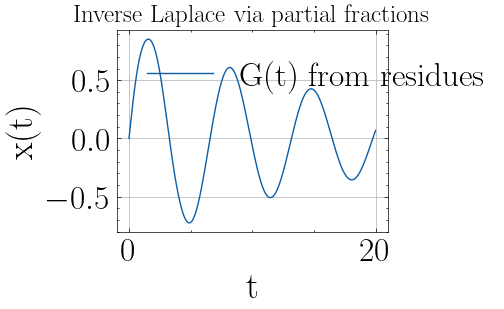

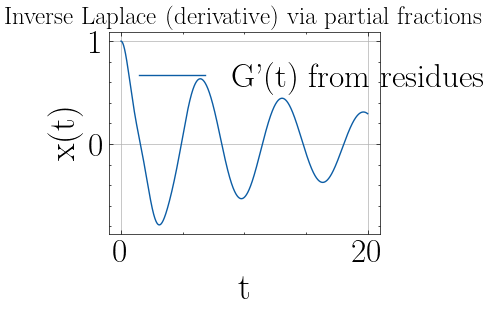

poles = [-0.05406432+0.95219024j -0.05406432-0.95219024j -0.44593568+3.28559208j
 -0.44593568-3.28559208j]
dt = 0.001
omega_max = 3.2855920822158398
samples per fastest period = 1912.344913779478
max real part of poles = -0.05406431944980634
G[0] = 0.0
Gdot[0] = 1.0000000000000002
[[2.  0. ]
 [0.  0.5]]
1.6613111354837284 1.661293062065226 1.6598704470216457


Dynamics: 100%|██████████| 20000/20000 [00:53<00:00, 373.01it/s]


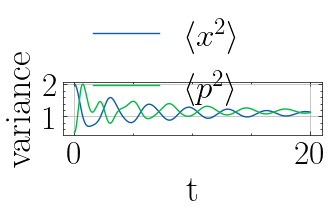

In [21]:
def inverse_laplace_rational(B, A, enforce_real=True):

    B = np.atleast_1d(np.array(B, dtype=np.complex128))
    A = np.atleast_1d(np.array(A, dtype=np.complex128))

    r, p, k = residue(B, A)


    # tol = 1e-10
    # groups = []
    # used = np.zeros(len(p), dtype=bool)
    # for i in range(len(p)):
    #     if used[i]:
    #         continue
    #     mask = np.abs(p - p[i]) < tol
    #     idx = np.where(mask)[0]
    #     used[idx] = True
    #     groups.append((p[i], r[idx]))

    # def x_of_t(t):
    #     t = np.asarray(t, dtype=float)
    #     out = np.zeros_like(t, dtype=np.complex128)
    #     for pole, rlist in groups:
    #         for m, rm in enumerate(rlist, start=1):
    #             out += rm * (t**(m-1) / math.factorial(m-1)) * np.exp(pole * t)

    #     if enforce_real and np.allclose(B.imag, 0, atol=1e-12) and np.allclose(A.imag, 0, atol=1e-12):
    #         out = out.real  # drop numerical imag noise
    #     return out

    def x_of_t(t):
        t = np.asarray(t, dtype=float)
        out = np.zeros_like(t, dtype=np.complex128)
        for ri, pi in zip(r, p):
            out += ri * np.exp(pi * t)

        if enforce_real and np.allclose(B.imag, 0) and np.allclose(A.imag, 0):
            out = np.real_if_close(out, tol=1000000)
        return out

    info = {"residues": r, "poles": p, "direct_poly": k} #, "groups": groups
    return x_of_t, info

def derivatives_from_residues(t, residues, poles, enforce_real=True):
    t = np.asarray(t, dtype=float)

    G    = np.zeros_like(t, dtype=np.complex128)
    Gdot = np.zeros_like(t, dtype=np.complex128)
    Gddot= np.zeros_like(t, dtype=np.complex128)

    for r, p in zip(residues, poles):
        ep = np.exp(p * t)
        G     += r * ep
        Gdot  += r * p * ep
        Gddot += r * p * p * ep

    if enforce_real:
        G     = np.real_if_close(G)
        Gdot  = np.real_if_close(Gdot)
        Gddot = np.real_if_close(Gddot)

    return G, Gdot, Gddot


B = [1, gamma, alpha2*gamma]
#Bprime = [1, gamma, alpha2*gamma, 0]
A = [1,gamma,alpha2*gamma+Omega_S**2,gamma*Omega_S**2,alpha2*gamma*Omega_S**2-gamma*alpha1*alpha2]
G_of_t, info = inverse_laplace_rational(B, A)
#Gprime_of_t_comparison, info_2  = inverse_laplace_rational(Bprime, A)
G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])

# evaluate inverse Laplace
Gdot = Gprime_of_t

# plot
plt.figure()
plt.plot(times, G, label="G(t) from residues")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Inverse Laplace via partial fractions")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(times, Gdot, label="G'(t) from residues")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Inverse Laplace (derivative) via partial fractions")
plt.grid(True)
plt.legend()
plt.show()

print("poles =", info["poles"])
dt = times[1] - times[0]
omega_max = np.max(np.abs(np.imag(info["poles"])))
print("dt =", dt)
print("omega_max =", omega_max)
print("samples per fastest period =", 2*np.pi / (omega_max * dt))
print("max real part of poles =", np.max(np.real(info["poles"])))
print("G[0] =", G[0])
print("Gdot[0] =", Gdot[0])

def coth(z):
    return np.cosh(z) / np.sinh(z)

def csch2(z):
    s = np.sinh(z)
    return 1.0 / (s*s)

def noise_kernel_residue(t, gamma, alpha1, alpha2, Temp, Nmats=20000, delta_eps=1e-10, prefactor=1/np.pi):

    scalar_input = np.isscalar(t)
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    t = np.abs(t)
    Delta = 4.0*alpha2*gamma - gamma*gamma
    beta = 1.0/Temp
    a = 0.5*beta

    def coth(z):
        return np.cosh(z) / np.sinh(z)

    def csch2(z):
        s = np.sinh(z)
        return 1.0/(s*s)

    if abs(Delta) < delta_eps:
        w0 = 0.5j * gamma
        exp0 = np.exp(1j * w0 * t)
        coth0 = coth(a * w0)
        fprime = (a * (-csch2(a * w0)) + 1j * t * coth0) * exp0
        nu_sys = (np.pi * gamma * alpha1 * alpha2 / 2.0) * np.real(fprime)
    else:
        sqrtDelta = np.sqrt(Delta + 0j)  
        w_plus  = 0.5j*gamma + 0.5*sqrtDelta
        w_minus = 0.5j*gamma - 0.5*sqrtDelta

        term_plus  = coth(a * w_plus)  * np.exp(1j * w_plus  * t)
        term_minus = coth(a * w_minus) * np.exp(1j * w_minus * t)

        pref = (np.pi * gamma * alpha1 * alpha2) / (2.0 * sqrtDelta)
        nu_sys = np.real(pref * (term_plus - term_minus))

    n = np.arange(1, Nmats+1, dtype=np.float64)
    nu_n = (2.0*np.pi/beta) * n

    denom = (alpha2*gamma + nu_n**2)**2 - (gamma*nu_n)**2
    expo = np.exp(-nu_n[:, None] * t[None, :])
    mats_sum = (nu_n/denom)[:, None] * expo

    nu_M = -(2.0*np.pi * gamma*gamma * alpha1 * alpha2 / beta) * mats_sum.sum(axis=0)

    out = prefactor * (nu_sys + nu_M)
    return float(out[0]) if scalar_input else out

def evolve_dynamics(t_array,x0,p0,sigma0,alpha1,alpha2,Temp,mass=1.0):
    dt = t_array[1] - t_array[0]
    N  = len(t_array)
    G_r    = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    x_mean = Gdot_r * x0 + (G_r / mass) * p0
    p_mean = mass * Gddot_r * x0 + Gdot_r * p0
    sx0  = sigma0[0, 0]
    sp0  = sigma0[1, 1]
    sxp0 = sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a = mass * Gddot_r
    b = Gdot_r
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array])/mass
    print(nu_grid[0], nu_grid[1], nu_grid[10])
    var_x_bath  = np.zeros(N)
    var_p_bath = np.zeros(N)
    for i in tqdm(range(1, N), desc="Dynamics"):
        G_slice  = G_r[:i+1][::-1] # Compute G(t_i - t_j) for j=0,...,i and reverse it
        Gd_slice = Gdot_r[:i+1][::-1] # Compute Gdot(t_i - t_j) for j=0,...,i and reverse it
        nu_segment = nu_grid[:i+1]  # nu(0), nu(dt), ..., nu(i*dt)

        yG  = matmul_toeplitz((nu_segment, nu_segment), G_slice)
        yGd = matmul_toeplitz((nu_segment, nu_segment), Gd_slice)

        var_x_bath[i]  = np.dot(G_slice,  yG)  * dt**2
        var_p_bath[i] = np.dot(Gd_slice, yGd) * dt**2
        
    var_x  = var_x_sys + var_x_bath
    var_p = var_p_sys + var_p_bath
    # def bath_var_direct(i, G_r, nu_grid, dt):
    #     acc = 0.0
    #     for j in range(i + 1):
    #         for k in range(i + 1):
    #             acc += G_r[i - j] * nu_grid[abs(j - k)] * G_r[i - k]
    #     return acc * dt**2

    # ncheck = 2000
    # var_x_bath_direct = np.zeros(ncheck)

    # for i in range(1, ncheck):
    #     var_x_bath_direct[i] = bath_var_direct(i, G_r, nu_grid, dt)

    # plt.figure()
    # plt.plot(times[:ncheck], var_x_bath[:ncheck], label="Toeplitz")
    # plt.plot(times[:ncheck], var_x_bath_direct, "--", label="Direct")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    # print("max abs diff =", np.max(np.abs(var_x_bath[:ncheck] - var_x_bath_direct)))
    # print("rel diff =", np.max(np.abs(var_x_bath[:ncheck] - var_x_bath_direct)) / np.max(np.abs(var_x_bath_direct)))
    return {"time":   t_array, "x_mean": x_mean, "var_x":  var_x, "p_mean": p_mean, "var_p": var_p, "G": G_r, "Gdot": Gdot_r}

x0 = 1.0
p0 = 0.0
sigma0 = np.array([[2.0 / Omega_S_bare, 0], [0, Omega_S_bare / 2.0]])
#sigma0 = np.array([[0.65126, 0], [0, 1.27952]])
print(sigma0)
sol = evolve_dynamics(times,x0,p0,sigma0,alpha1,alpha2,temp,mass)

plt.subplot(2, 1, 2)
plt.plot(sol["time"], sol["var_x"], label=r"$\langle x^2 \rangle$")
plt.plot(sol["time"], sol["var_p"], label=r"$\langle p^2 \rangle$")
plt.xlabel("t")
plt.ylabel("variance")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# PLOTS

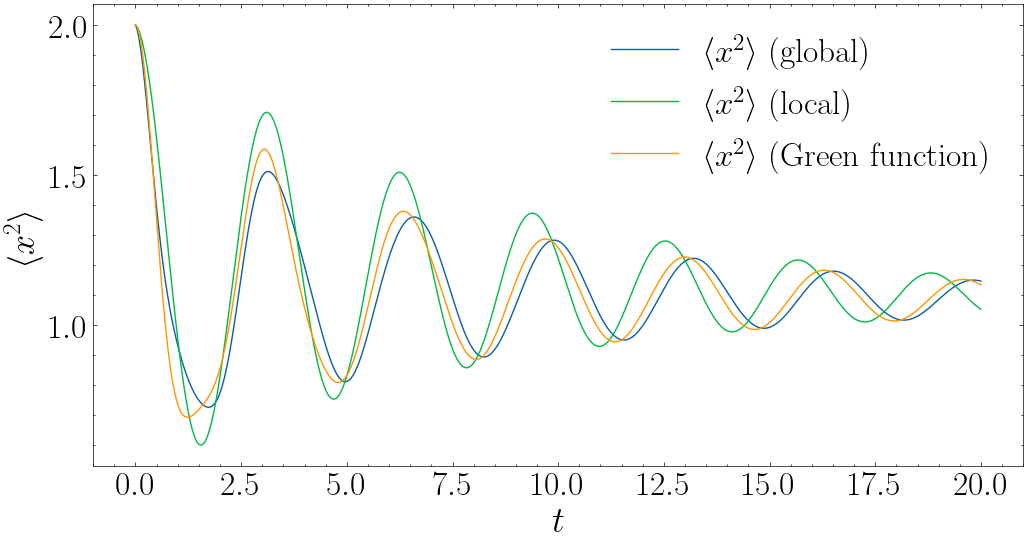

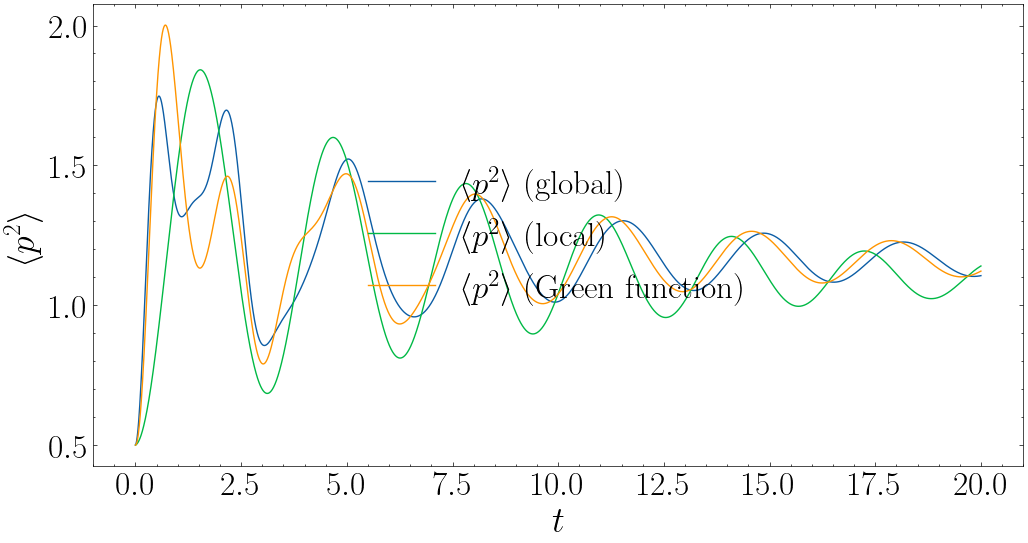

In [24]:
import scienceplots
plt.style.use(["science"])
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "axes.labelsize": 26,    # x- and y-label size
    "axes.titlesize": 18,    # title size
    "xtick.labelsize": 24,   # x-tick label size
    "ytick.labelsize": 24,   # y-tick label size
    "legend.fontsize": 24,   # legend text size
})

plt.figure(figsize=(12, 6))
plt.plot(times, var_xS_global, label=r"$\langle x^2 \rangle$ (global)")
plt.plot(times, var_xS_local,label=r"$\langle x^2 \rangle$ (local)")
plt.plot(sol["time"], sol["var_x"], label=r"$\langle x^2 \rangle$ (Green function)")
plt.xlabel(r"$t$")
plt.ylabel(r"$\langle x^2 \rangle$")
plt.legend()
#plt.grid(True) 
#plt.savefig("variance_x_comparison_zoomed.pdf", format = "pdf", bbox_inches='tight')     
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(times, var_pS_global, label=r"$\langle p^2 \rangle$ (global)")
plt.plot(times, var_pS_local, label=r"$\langle p^2 \rangle$ (local)")
plt.plot(sol["time"], sol["var_p"], label=r"$\langle p^2 \rangle$ (Green function)")
plt.xlabel(r"$t$")
plt.ylabel(r"$\langle p^2 \rangle$")
plt.legend(loc='center')
#plt.grid(True) 
#plt.savefig("variance_p_comparison_zoomed.pdf", format = "pdf", bbox_inches='tight')     
plt.show()

In [8]:
# Save covariance-related results for all approaches in one binary file
np.savez(
    "covariances_approaches.npz",
    times=times,
    cov_local=cov_t_local,
    cov_global=cov_t,
    var_x_exact=sol["var_x"],
    var_x_local=var_xS_local,
    var_x_global=var_xS_global,
    var_p_local=var_pS_local,
    var_p_global=var_pS_global,
)

# Save an easy-to-open CSV summary of key second moments vs time
summary = np.column_stack(
    [
        times,
        var_xS_local,
        var_xS_global,
        sol["var_x"],
        var_pS_local,
        var_pS_global,
    ]
)

np.savetxt(
    "covariance_summary.csv",
    summary,
    delimiter=",",
    header="time,var_x_local,var_x_global,var_x_exact,var_p_local,var_p_global",
    comments="",
)

print("Saved covariances_approaches.npz and covariance_summary.csv")

Saved covariances_approaches.npz and covariance_summary.csv
